# Diffusion and reaction in a catalyst pellet: a flat teaching notebook

**Question.** How much of a spherical pellet's volume is used when a reactant
diffuses in and reacts? The answer is the effectiveness factor $\eta$.

**Model** (dimensionless, radius 1, surface concentration 1):

$$\frac{1}{r^2}\frac{d}{dr}\left(r^2 \frac{dc}{dr}\right) = \phi^2 c^m,
\qquad \frac{dc}{dr}\Big|_{r=0} = 0, \qquad c(1) = 1,
\qquad \eta = \frac{3}{\phi^2}\frac{dc}{dr}\Big|_{r=1}.$$

**Assumptions:** isothermal, constant effective diffusivity, no film resistance,
power-law kinetics of order $m$.

This notebook is deliberately flat: no class, every discrete operator is a named
matrix, and each step is explained before it is built. For a model you will
extend and reuse, see the class-based exemplars instead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pymrm import NumJac, compute_boundary_values, construct_div, construct_grad, newton

## Parameters and grid

Finite volumes: `n` cells between the faces `r_f`; unknowns live at the cell
centres `r_c`. One field, so the state has shape `(n, 1)`: pymrm keeps a field
axis even for a single field.

In [2]:
phi, m = 2.0, 1          # Thiele modulus and reaction order
n = 100
r_f = np.linspace(0.0, 1.0, n + 1)
r_c = 0.5 * (r_f[:-1] + r_f[1:])
shape = (n, 1)

## Boundary conditions

pymrm writes every boundary condition as $a\,\partial c/\partial n + b\,c = d$
with $n$ the **outward** normal. At $r=0$ symmetry means $dc/dr = 0$
(a = 1, b = 0, d = 0); at $r=1$ the surface value is fixed (a = 0, b = 1, d = 1).
`describe_bc` prints what the dictionaries mean, to catch sign errors.

In [3]:
bc = ({"a": 1.0, "b": 0.0, "d": 0.0},   # r = 0: dc/dr = 0
      {"a": 0.0, "b": 1.0, "d": 1.0})   # r = 1: c = 1
try:
    from pymrm import describe_bc          # pymrm after 2.3.1
    print(describe_bc(bc, r_f, axis_name="r"))
except ImportError:
    pass

lower (r=0, outward normal -r): -1*dc/dr + 0*c = 0  [Neumann]
upper (r=1, outward normal +r): 0*dc/dr + 1*c = 1  [Dirichlet]


## The discrete operators

The diffusive flux at the faces is $-dc/dr$: `grad` maps cell values to face
gradients, and `grad_bc` holds the boundary contribution. `div` maps face fluxes
to cell balances; `nu=2` makes it the spherical divergence
$\frac{1}{r^2}\frac{d}{dr}(r^2\,\cdot)$. Their product is the constant part of
the Jacobian.

In [4]:
grad, grad_bc = construct_grad(shape, r_f, r_c, bc)
div = construct_div(shape, r_f, nu=2)           # nu=2: sphere
jac_diffusion = (div @ -grad).tocsc()          # constant: assembled once
g_diffusion_bc = (div @ -grad_bc).toarray()     # boundary contribution
print("Jacobian of the diffusion term:", jac_diffusion.shape, "nonzeros:", jac_diffusion.nnz)

Jacobian of the diffusion term: (100, 100) nonzeros: 298


## The reaction term and its Jacobian

The reaction is local: each cell's rate depends only on its own concentration.
`NumJac` builds that (diagonal) Jacobian by finite differences. The total
Jacobian is the **sum** of the diffusion matrix and the reaction Jacobian.

In [5]:
numjac = NumJac(shape)

def reaction(c):
    return phi**2 * np.maximum(c, 0.0) ** m

def residual(c):
    g_rxn, jac_rxn = numjac(reaction, c.reshape(shape))
    g = g_diffusion_bc + jac_diffusion @ c.reshape(-1, 1) + g_rxn.reshape(-1, 1)
    return g, jac_diffusion + jac_rxn

## Solve with Newton and compute $\eta$

`compute_boundary_values` returns the gradient at the surface face, which is
what the operator transports.

converged: True in 2 iterations; eta = 0.805956


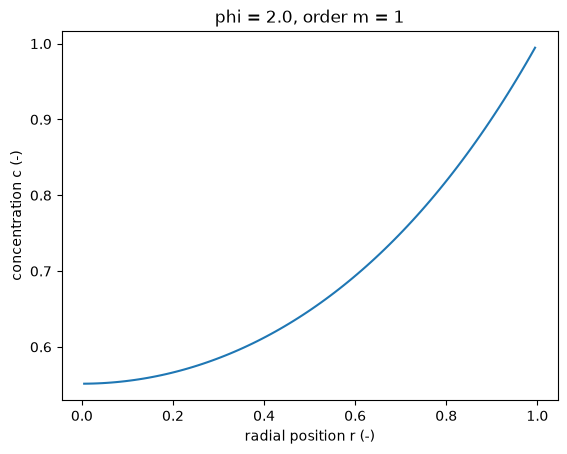

In [6]:
result = newton(residual, np.ones(shape))
c = result.x.reshape(shape)
_, _, _, grad_surface = compute_boundary_values(c, r_f, r_c, bc)
eta = 3.0 * float(np.ravel(grad_surface)[0]) / phi**2
print(f"converged: {result.success} in {result.nit} iterations; eta = {eta:.6f}")

plt.plot(r_c, c[:, 0])
plt.xlabel("radial position r (-)")
plt.ylabel("concentration c (-)")
plt.title(f"phi = {phi}, order m = {m}")
plt.show()

## Checks

1. **Closed form.** For $m = 1$: $\eta = \frac{3}{\phi^2}(\phi\coth\phi - 1)$.
2. **Grid refinement.** The error should fall with the square of the cell size
   (observed order 2).
3. **Break row.** Solving the same problem as a slab (`nu=0`) must change $\eta$:
   otherwise the checks cannot see the geometry.

In [7]:
def solve_eta(n, nu=2):
    r_f = np.linspace(0.0, 1.0, n + 1)
    shape = (n, 1)
    grad, grad_bc = construct_grad(shape, r_f, bc=bc)
    div = construct_div(shape, r_f, nu=nu)
    jac_d, g_d = (div @ -grad).tocsc(), (div @ -grad_bc).toarray()
    nj = NumJac(shape)
    def res(c):
        g_r, j_r = nj(reaction, c.reshape(shape))
        return g_d + jac_d @ c.reshape(-1, 1) + g_r.reshape(-1, 1), jac_d + j_r
    c = newton(res, np.ones(shape)).x.reshape(shape)
    _, _, _, gs = compute_boundary_values(c, r_f, bc=bc)
    return (nu + 1) * float(np.ravel(gs)[0]) / phi**2

exact = 3.0 / phi**2 * (phi / np.tanh(phi) - 1.0)
ns = (25, 50, 100, 200)
errors = [abs(solve_eta(k) - exact) for k in ns]
for k, e in zip(ns, errors):
    print(f"n = {k:4d}: |eta - exact| = {e:.2e}")
orders = np.log2(np.array(errors[:-1]) / np.array(errors[1:]))
print("observed orders:", np.round(orders, 3))
print(f"slab instead of sphere moves eta by {abs(solve_eta(100, nu=0) - exact) / exact:.0%}")

n =   25: |eta - exact| = 2.63e-04
n =   50: |eta - exact| = 6.47e-05
n =  100: |eta - exact| = 1.61e-05
n =  200: |eta - exact| = 4.00e-06
observed orders: [2.022 2.012 2.006]
slab instead of sphere moves eta by 40%
